In [1]:
import os
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch.optim as optim
from sklearn.metrics import accuracy_score
from torch import nn, einsum
from einops import rearrange, repeat

In [2]:
class CustomDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.class_labels = ['glioma', 'meningioma','notumor','pituitary']
        self.images, self.labels = self.load_data()

    def load_data(self):
        images = []
        labels = []

        for label in self.class_labels:
            label_directory = os.path.join(self.data_dir, label)
            label_idx = self.class_labels.index(label)

            for filename in os.listdir(label_directory):
                img_path = os.path.join(label_directory, filename)
                images.append(img_path)
                labels.append(label_idx)
                # print(label_idx)

        return images, labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]

        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img.unsqueeze(0), label


data_dir_train = r"Dataset_4C"
# data_dir_test = r"Dataset_4C/Testing"


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

custom_dataset = CustomDataset(data_dir_train, transform=transform)
# custom_dataset_test = CustomDataset(data_dir_test, transform=transform)



train_size = int(0.8 * len(custom_dataset))
test_size = len(custom_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(custom_dataset, [train_size, test_size])

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)


print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of testing samples: {len(test_dataset)}")

Number of training samples: 5618
Number of testing samples: 1405


In [3]:
import torch
from torch import nn, einsum
import numpy as np
from einops import rearrange, repeat


class CyclicShift(nn.Module):
    def __init__(self, displacement):
        super().__init__()
        self.displacement = displacement

    def forward(self, x):
        return torch.roll(x, shifts=(self.displacement, self.displacement), dims=(1, 2))


class Residual(nn.Module):
    def __init__(self, fn):
        super().__init__()
        self.fn = fn

    def forward(self, x, **kwargs):
        return self.fn(x, **kwargs) + x


class PreNorm(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.fn = fn

    def forward(self, x, **kwargs):
        return self.fn(self.norm(x), **kwargs)


class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, dim),
        )

    def forward(self, x):
        return self.net(x)


def create_mask(window_size, displacement, upper_lower, left_right):
    mask = torch.zeros(window_size ** 2, window_size ** 2)

    if upper_lower:
        mask[-displacement * window_size:, :-displacement * window_size] = float('-inf')
        mask[:-displacement * window_size, -displacement * window_size:] = float('-inf')

    if left_right:
        mask = rearrange(mask, '(h1 w1) (h2 w2) -> h1 w1 h2 w2', h1=window_size, h2=window_size)
        mask[:, -displacement:, :, :-displacement] = float('-inf')
        mask[:, :-displacement, :, -displacement:] = float('-inf')
        mask = rearrange(mask, 'h1 w1 h2 w2 -> (h1 w1) (h2 w2)')

    return mask


def get_relative_distances(window_size):
    indices = torch.tensor(np.array([[x, y] for x in range(window_size) for y in range(window_size)]))
    distances = indices[None, :, :] - indices[:, None, :]
    return distances


class WindowAttention(nn.Module):
    def __init__(self, dim, heads, head_dim, shifted, window_size, relative_pos_embedding):
        super().__init__()
        inner_dim = head_dim * heads

        self.heads = heads
        self.scale = head_dim ** -0.5
        self.window_size = window_size
        self.relative_pos_embedding = relative_pos_embedding
        self.shifted = shifted

        if self.shifted:
            displacement = window_size // 2
            self.cyclic_shift = CyclicShift(-displacement)
            self.cyclic_back_shift = CyclicShift(displacement)
            self.upper_lower_mask = nn.Parameter(create_mask(window_size=window_size, displacement=displacement,
                                                             upper_lower=True, left_right=False), requires_grad=False)
            self.left_right_mask = nn.Parameter(create_mask(window_size=window_size, displacement=displacement,
                                                            upper_lower=False, left_right=True), requires_grad=False)

        self.to_qkv = nn.Linear(dim, inner_dim * 3, bias=False)

        if self.relative_pos_embedding:
            self.relative_indices = get_relative_distances(window_size) + window_size - 1
            self.pos_embedding = nn.Parameter(torch.randn(2 * window_size - 1, 2 * window_size - 1))
        else:
            self.pos_embedding = nn.Parameter(torch.randn(window_size ** 2, window_size ** 2))

        self.to_out = nn.Linear(inner_dim, dim)

    def forward(self, x):
        if self.shifted:
            x = self.cyclic_shift(x)

        b, n_h, n_w, _, h = *x.shape, self.heads

        qkv = self.to_qkv(x).chunk(3, dim=-1)
        nw_h = n_h // self.window_size
        nw_w = n_w // self.window_size

        q, k, v = map(
            lambda t: rearrange(t, 'b (nw_h w_h) (nw_w w_w) (h d) -> b h (nw_h nw_w) (w_h w_w) d',
                                h=h, w_h=self.window_size, w_w=self.window_size), qkv)

        dots = einsum('b h w i d, b h w j d -> b h w i j', q, k) * self.scale

        if self.relative_pos_embedding:
            dots += self.pos_embedding[self.relative_indices[:, :, 0], self.relative_indices[:, :, 1]]
        else:
            dots += self.pos_embedding

        if self.shifted:
            dots[:, :, -nw_w:] += self.upper_lower_mask
            dots[:, :, nw_w - 1::nw_w] += self.left_right_mask

        attn = dots.softmax(dim=-1)

        out = einsum('b h w i j, b h w j d -> b h w i d', attn, v)
        out = rearrange(out, 'b h (nw_h nw_w) (w_h w_w) d -> b (nw_h w_h) (nw_w w_w) (h d)',
                        h=h, w_h=self.window_size, w_w=self.window_size, nw_h=nw_h, nw_w=nw_w)
        out = self.to_out(out)

        if self.shifted:
            out = self.cyclic_back_shift(out)
        return out


class SwinBlock(nn.Module):
    def __init__(self, dim, heads, head_dim, mlp_dim, shifted, window_size, relative_pos_embedding):
        super().__init__()
        self.attention_block = Residual(PreNorm(dim, WindowAttention(dim=dim,
                                                                     heads=heads,
                                                                     head_dim=head_dim,
                                                                     shifted=shifted,
                                                                     window_size=window_size,
                                                                     relative_pos_embedding=relative_pos_embedding)))
        self.mlp_block = Residual(PreNorm(dim, FeedForward(dim=dim, hidden_dim=mlp_dim)))

    def forward(self, x):
        x = self.attention_block(x)
        x = self.mlp_block(x)
        return x


class PatchMerging(nn.Module):
    def __init__(self, in_channels, out_channels, downscaling_factor):
        super().__init__()
        self.downscaling_factor = downscaling_factor
        self.patch_merge = nn.Unfold(kernel_size=downscaling_factor, stride=downscaling_factor, padding=0)
        self.linear = nn.Linear(in_channels * downscaling_factor ** 2, out_channels)

    def forward(self, x):
        b, c, h, w = x.shape
        new_h, new_w = h // self.downscaling_factor, w // self.downscaling_factor
        x = self.patch_merge(x).view(b, -1, new_h, new_w).permute(0, 2, 3, 1)
        x = self.linear(x)
        return x


class StageModule(nn.Module):
    def __init__(self, in_channels, hidden_dimension, layers, downscaling_factor, num_heads, head_dim, window_size,
                 relative_pos_embedding):
        super().__init__()
        assert layers % 2 == 0, 'Stage layers need to be divisible by 2 for regular and shifted block.'

        self.patch_partition = PatchMerging(in_channels=in_channels, out_channels=hidden_dimension,
                                            downscaling_factor=downscaling_factor)

        self.layers = nn.ModuleList([])
        for _ in range(layers // 2):
            self.layers.append(nn.ModuleList([
                SwinBlock(dim=hidden_dimension, heads=num_heads, head_dim=head_dim, mlp_dim=hidden_dimension * 4,
                          shifted=False, window_size=window_size, relative_pos_embedding=relative_pos_embedding),
                SwinBlock(dim=hidden_dimension, heads=num_heads, head_dim=head_dim, mlp_dim=hidden_dimension * 4,
                          shifted=True, window_size=window_size, relative_pos_embedding=relative_pos_embedding),
            ]))

    def forward(self, x):
        x = self.patch_partition(x)
        for regular_block, shifted_block in self.layers:
            x = regular_block(x)
            x = shifted_block(x)
        return x.permute(0, 3, 1, 2)


class SwinTransformer(nn.Module):
    def __init__(self, *, hidden_dim, layers, heads, channels=3, num_classes=1000, head_dim=32, window_size=7,
                 downscaling_factors=(4, 2, 2, 2), relative_pos_embedding=True):
        super().__init__()

        self.stage1 = StageModule(in_channels=channels, hidden_dimension=hidden_dim, layers=layers[0],
                                  downscaling_factor=downscaling_factors[0], num_heads=heads[0], head_dim=head_dim,
                                  window_size=window_size, relative_pos_embedding=relative_pos_embedding)
        self.stage2 = StageModule(in_channels=hidden_dim, hidden_dimension=hidden_dim * 2, layers=layers[1],
                                  downscaling_factor=downscaling_factors[1], num_heads=heads[1], head_dim=head_dim,
                                  window_size=window_size, relative_pos_embedding=relative_pos_embedding)
        self.stage3 = StageModule(in_channels=hidden_dim * 2, hidden_dimension=hidden_dim * 4, layers=layers[2],
                                  downscaling_factor=downscaling_factors[2], num_heads=heads[2], head_dim=head_dim,
                                  window_size=window_size, relative_pos_embedding=relative_pos_embedding)
        self.stage4 = StageModule(in_channels=hidden_dim * 4, hidden_dimension=hidden_dim * 8, layers=layers[3],
                                  downscaling_factor=downscaling_factors[3], num_heads=heads[3], head_dim=head_dim,
                                  window_size=window_size, relative_pos_embedding=relative_pos_embedding)

        self.mlp_head = nn.Sequential(
            nn.LayerNorm(hidden_dim * 8),
            nn.Linear(hidden_dim * 8, num_classes)
        )

    def forward(self, img):
        x = self.stage1(img)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = x.mean(dim=[2, 3])
        return self.mlp_head(x)

def swin_t(hidden_dim=96, layers=(2, 2, 6, 2), heads=(3, 6, 12, 24), **kwargs):
    return SwinTransformer(hidden_dim=hidden_dim, layers=layers, heads=heads, **kwargs)


In [4]:
class LSTMSWINModel(nn.Module):
    def __init__(self, swin_transformer, lstm_input_size, lstm_hidden_size, num_classes):
        super(LSTMSWINModel, self).__init__()
        self.swin_transformer = swin_transformer
        self.lstm = nn.LSTM(input_size=lstm_input_size, hidden_size=lstm_hidden_size, batch_first=True)
        self.fc = nn.Linear(lstm_hidden_size, num_classes)

    def forward(self, images):
        print(images.shape)
        b, s, c, h, w = images.size()
        images = images.view(b * s, c, h, w) 

        swin_features = self.swin_transformer(images)

        swin_features = swin_features.view(b, s, -1)

        lstm_out, _ = self.lstm(swin_features)

        avg_pool = torch.mean(lstm_out, dim=1)

        output = self.fc(avg_pool)

        return output



In [5]:
swin_backbone = swin_t()
sample_input = torch.randn(1, 3, 224, 224)
swin_output = swin_backbone(sample_input)
lstm_input_size = swin_output.size(-1)
print(f"Swin output size: {swin_output.size()}, LSTM input size: {lstm_input_size}")

lstm_hidden_size = 128
num_classes = 4
lstm_swin_model = LSTMSWINModel(swin_backbone, lstm_input_size, lstm_hidden_size, num_classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lstm_swin_model = lstm_swin_model.to(device)

Swin output size: torch.Size([1, 1000]), LSTM input size: 1000


In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(lstm_swin_model.parameters(), lr=0.0001)

In [7]:
accuracy_list = []
test_loss_list = []

In [8]:
num_epochs = 100
for epoch in range(num_epochs):
    lstm_swin_model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = lstm_swin_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    lstm_swin_model.eval()
    test_loss = 0.0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = lstm_swin_model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    average_test_loss = test_loss / len(test_loader)
    accuracy = accuracy_score(all_labels, all_preds)
    accuracy_list.append(accuracy)
    test_loss_list.append(average_test_loss)
    print(f"Epoch {epoch + 1}/{num_epochs}, Test Loss: {average_test_loss:.4f}, Test Accuracy: {accuracy:.4f}")


Epoch 1/100, Test Loss: 1.1288, Test Accuracy: 0.4690
Epoch 2/100, Test Loss: 1.1036, Test Accuracy: 0.4940
Epoch 3/100, Test Loss: 0.8538, Test Accuracy: 0.6605
Epoch 4/100, Test Loss: 0.7547, Test Accuracy: 0.7068
Epoch 5/100, Test Loss: 0.5797, Test Accuracy: 0.7886
Epoch 6/100, Test Loss: 0.5399, Test Accuracy: 0.8028
Epoch 7/100, Test Loss: 0.4904, Test Accuracy: 0.8185
Epoch 8/100, Test Loss: 0.7826, Test Accuracy: 0.6811
Epoch 9/100, Test Loss: 0.4661, Test Accuracy: 0.8306
Epoch 10/100, Test Loss: 0.4276, Test Accuracy: 0.8427
Epoch 11/100, Test Loss: 0.3988, Test Accuracy: 0.8534
Epoch 12/100, Test Loss: 0.4369, Test Accuracy: 0.8199
Epoch 13/100, Test Loss: 0.4366, Test Accuracy: 0.8370
Epoch 14/100, Test Loss: 0.3627, Test Accuracy: 0.8726
Epoch 15/100, Test Loss: 0.3613, Test Accuracy: 0.8584
Epoch 16/100, Test Loss: 0.3757, Test Accuracy: 0.8733
Epoch 17/100, Test Loss: 0.3583, Test Accuracy: 0.8683
Epoch 18/100, Test Loss: 0.3156, Test Accuracy: 0.8904
Epoch 19/100, Test 

In [9]:
torch.save(lstm_swin_model.state_dict(),"SWIN-LSTM-4C-model100.pth")

In [10]:
import torch
from torchvision import transforms
from PIL import Image
import numpy as np

# Assuming 'model' is your PyTorch model
# Assuming 'preprocess_image' is your image preprocessing function
def preprocess_image(img):
    if img is None or not isinstance(img, np.ndarray):
        raise ValueError("Image data is empty or invalid.")

    transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

    # Convert Gradio Image to PIL Image
    img_pil = Image.fromarray((img * 255).astype('uint8'), 'RGB')

    img = transform(img_pil)
    img = img.unsqueeze(0).unsqueeze(0)

    return img



def predict(image_path, model):
    # Load and preprocess the image
    
    img = Image.open(image_path).convert("RGB")
    img_array = np.array(img) / 255.0  # Normalize to [0, 1]
    img_tensor = preprocess_image(img_array)
    img_tensor = img_tensor.to(device)

    # Set the model to evaluation mode
    model.eval()

    # Perform the prediction
    with torch.no_grad():
        outputs = model(img_tensor)

    # Assuming softmax is used, convert to probabilities
    probabilities = torch.softmax(outputs, dim=1)

    # Assuming it's a binary classification (two classes)
    class_names = ['glioma', 'meningioma','notumor','pituitary']
    predicted_class = torch.argmax(probabilities, dim=1).item()
    predicted_class_name = class_names[predicted_class]

    return predicted_class_name, probabilities.cpu().numpy()

# Example usage:
image_path = "Dataset_4C\pituitary\Tr-pi_0010.jpg"
predicted_class, probabilities = predict(image_path, lstm_swin_model)
print(f"Predicted Class: {predicted_class}")
print(f"Class Probabilities: {probabilities}")


Predicted Class: pituitary
Class Probabilities: [[2.7736541e-04 7.8567490e-04 4.7576873e-04 9.9846125e-01]]


In [11]:
lstm_swin_model

LSTMSWINModel(
  (swin_transformer): SwinTransformer(
    (stage1): StageModule(
      (patch_partition): PatchMerging(
        (patch_merge): Unfold(kernel_size=4, dilation=1, padding=0, stride=4)
        (linear): Linear(in_features=48, out_features=96, bias=True)
      )
      (layers): ModuleList(
        (0): ModuleList(
          (0): SwinBlock(
            (attention_block): Residual(
              (fn): PreNorm(
                (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
                (fn): WindowAttention(
                  (to_qkv): Linear(in_features=96, out_features=288, bias=False)
                  (to_out): Linear(in_features=96, out_features=96, bias=True)
                )
              )
            )
            (mlp_block): Residual(
              (fn): PreNorm(
                (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
                (fn): FeedForward(
                  (net): Sequential(
                    (0): Linear(in_feat

In [12]:
torch.cuda.empty_cache()

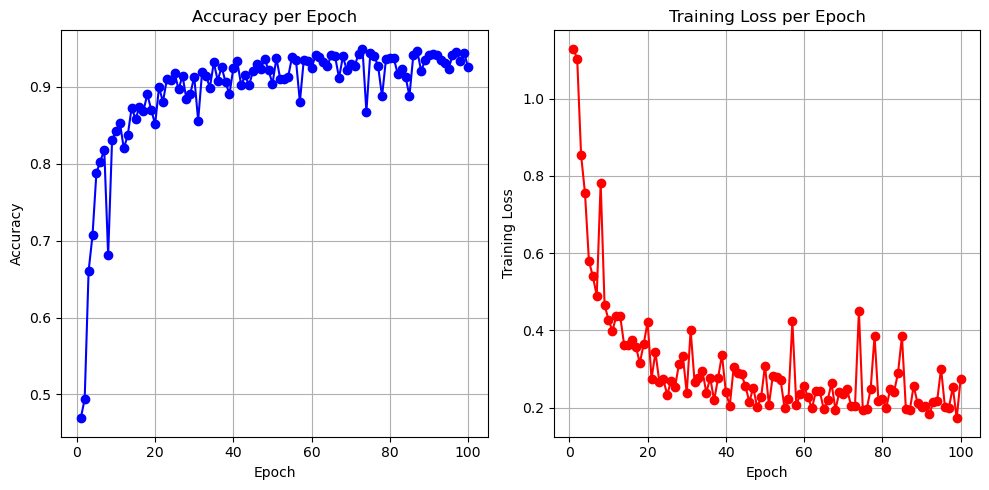

In [13]:
import matplotlib.pyplot as plt


num_epochs = len(accuracy_list)

# Plotting
plt.figure(figsize=(10, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), accuracy_list, marker='o', color='b')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

# Plot training loss
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), test_loss_list, marker='o', color='r')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.grid(True)

plt.tight_layout()
plt.show()
